In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv
import numpy as np
import ast
import seaborn as sns
import ast

from sklearn.metrics import mean_squared_error


TASC_VColor         = "#57B8FF"  # keep
TASC_permute_VColor = "#2176AE"  # keep
SC_VColor           = "#7ED957"  # fresher green, balanced against blue tones
RSC_VColor          = "#FF9F40"  # brighter orange, closer in vibrancy
CIM_VColor          = "#E255A1"  # vivid magenta, still distinct but harmonized


In [3]:
df1 = pd.read_csv("exp1_try7.csv")
df2 = pd.read_csv("exp1_try8.csv")
df = pd.concat([df1, df2], ignore_index=True)
header = ["seed_datagen", "seed_learning", "d_true", "N", "T", "T0", "N1", "d",
        "high_covariance", "loglikelihood", "loglikelihood_permute",
        "pred_tasc", "pred_tasc_permute", "pred_rsc", "pred_sc", "pred_cim", "cim_posterior_lower", "cim_posterior_upper",
        "tasc_target_var_estimates", "tasc_permute_target_var_estimates",
        "R_tasc", "R_tasc_permute",
        "ys", "ys_signal",
        ]

df = df.fillna("all small")

# Convert string representation of lists back to lists
list_cols = ['pred_tasc', 'pred_tasc_permute',
       'pred_rsc', 'pred_sc', 'pred_cim', 'cim_posterior_lower',
       'cim_posterior_upper', 'tasc_target_var_estimates','tasc_permute_target_var_estimates', 'ys', 'ys_signal']

for col in list_cols:
    df[col] = df[col].apply(ast.literal_eval)

# tasc lower/upper bound
df["tasc_upper"] = df.apply(lambda row: row["pred_tasc"] + 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)
df["tasc_lower"] = df.apply(lambda row: row["pred_tasc"] - 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)

# Compute RMSE for each method
pred_cols = ['pred_tasc', 'pred_tasc_permute', 'pred_rsc', 'pred_sc', 'pred_cim']

for col in pred_cols:
    df["rmse_"+col] = df.apply(
        lambda row: mean_squared_error(
            row["ys_signal"][row["T0"]:], row[col][row["T0"]:]
            # row["ys"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )

    df["rmse_"+col] = df.apply(
        lambda row: mean_squared_error(
            row["ys_signal"][row["T0"]:], row[col][row["T0"]:]
            # row["ys"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )

    for start in [0, 10, 20, 30, 40]:
        df["rmse_"+col+"_"+str(start)] = df.apply(
            lambda row: mean_squared_error(
                row["ys_signal"][row["T0"]+start:row["T0"]+start+10], row[col][row["T0"]+start:row["T0"]+start+10]
                # row["ys"][row["T0"]:row["T0"]+steps], row[col][row["T0"]:row["T0"]+steps]
            ),
            axis=1
        )
df.head()

,seed_datagen,seed_learning,d_true,N,T,T0,N1,d,high_covariance,loglikelihood,...,rmse_pred_sc_10,rmse_pred_sc_20,rmse_pred_sc_30,rmse_pred_sc_40,rmse_pred_cim,rmse_pred_cim_0,rmse_pred_cim_10,rmse_pred_cim_20,rmse_pred_cim_30,rmse_pred_cim_40
0,0,1000,5,50,100,50,1000,5,all small,-2384.538818,...,0.012089,0.009050,0.006748,0.003162,0.005510,0.002957,0.012211,0.004104,0.006860,0.001417
1,0,1000,5,50,100,50,1000,5,Q,-2478.348389,...,0.069034,0.137217,0.113868,0.081683,0.114980,0.031700,0.079067,0.159633,0.153881,0.150619
2,0,1000,5,50,100,50,1000,5,R,-4320.210938,...,0.278547,0.201129,0.393728,0.185543,1.177804,1.931220,1.037489,1.081607,1.171124,0.667582
3,0,1000,5,50,100,50,1000,5,both,-4451.335449,...,0.448206,1.208674,0.753689,0.523018,0.946605,0.757717,1.035566,1.128367,1.392262,0.419115
4,1,1000,5,50,100,50,1000,5,all small,-2301.597900,...,0.002944,0.001901,0.004306,0.003586,0.004951,0.002314,0.005210,0.003734,0.005131,0.008365


In [4]:
# df["ys"].apply(np.min)

for variance in df["high_covariance"].unique():
    print("high_covariance:", variance)



    data_subset = df[df["high_covariance"]==variance]["ys"].to_list()
    data_subset_signal = df[df["high_covariance"]==variance]["ys_signal"].to_list()
    data_subset = np.array(data_subset)
    data_subset_signal = np.array(data_subset_signal)

    print("average noise: ", np.mean(np.abs(data_subset - data_subset_signal)))
    print("average signal: ", np.mean(np.abs(data_subset_signal)))
    print("average signal/noise: ", np.mean(np.abs(data_subset_signal))/np.mean(np.abs(data_subset - data_subset_signal)))
    print("average std noise: ", np.mean(np.std(data_subset - data_subset_signal, axis=1)))
    print("average std signal: ", np.mean(np.std(data_subset_signal, axis=1)))
    print()
    # print(df_ys)


high_covariance: all small
average noise:  0.08392061707581847
average signal:  0.48426491507557634
average signal/noise:  5.7705118473814965
average std noise:  0.10394947047688907
average std signal:  0.4718796484809449

high_covariance: Q
average noise:  0.08392061707581847
average signal:  2.665304450065404
average signal/noise:  31.759829025773517
average std noise:  0.10394947047688907
average std signal:  3.011622703501184

high_covariance: R
average noise:  0.8365461586961982
average signal:  0.4840756450509892
average signal/noise:  0.578659814546811
average std noise:  1.0387059480034688
average std signal:  0.47188775406599737

high_covariance: both
average noise:  0.8365461586961982
average signal:  2.662403122218983
average signal/noise:  3.1826135289037487
average std noise:  1.0387059480034688
average std signal:  3.0066996351840873



In [5]:
df.head()

,seed_datagen,seed_learning,d_true,N,T,T0,N1,d,high_covariance,loglikelihood,...,rmse_pred_sc_10,rmse_pred_sc_20,rmse_pred_sc_30,rmse_pred_sc_40,rmse_pred_cim,rmse_pred_cim_0,rmse_pred_cim_10,rmse_pred_cim_20,rmse_pred_cim_30,rmse_pred_cim_40
0,0,1000,5,50,100,50,1000,5,all small,-2384.538818,...,0.012089,0.009050,0.006748,0.003162,0.005510,0.002957,0.012211,0.004104,0.006860,0.001417
1,0,1000,5,50,100,50,1000,5,Q,-2478.348389,...,0.069034,0.137217,0.113868,0.081683,0.114980,0.031700,0.079067,0.159633,0.153881,0.150619
2,0,1000,5,50,100,50,1000,5,R,-4320.210938,...,0.278547,0.201129,0.393728,0.185543,1.177804,1.931220,1.037489,1.081607,1.171124,0.667582
3,0,1000,5,50,100,50,1000,5,both,-4451.335449,...,0.448206,1.208674,0.753689,0.523018,0.946605,0.757717,1.035566,1.128367,1.392262,0.419115
4,1,1000,5,50,100,50,1000,5,all small,-2301.597900,...,0.002944,0.001901,0.004306,0.003586,0.004951,0.002314,0.005210,0.003734,0.005131,0.008365


In [6]:
# df = best_df.copy()
id_vars = ["high_covariance"]


value_vars = []
# Compute RMSE for each method
pred_cols = ['pred_tasc', 'pred_tasc_permute', 'pred_rsc', 'pred_sc', 'pred_cim']

for col in pred_cols:
    for start in [0, 10, 20, 30, 40]:
        value_vars += ["rmse_"+col+"_"+str(start)]

# Melt in one go
df_long = df.melt(
    id_vars=id_vars,
    value_vars= value_vars,
    value_name="rmse",
    var_name="variable"
)


df_long[["method", "period"]] = df_long["variable"].str.extract(r"rmse_pred_(\w+)_(\d+)")
df_long["method"] = df_long["method"].str.upper()
df_long

,high_covariance,variable,rmse,method,period
0,all small,rmse_pred_tasc_0,0.010482,TASC,0
1,Q,rmse_pred_tasc_0,0.024110,TASC,0
2,R,rmse_pred_tasc_0,0.154884,TASC,0
3,both,rmse_pred_tasc_0,0.113309,TASC,0
4,all small,rmse_pred_tasc_0,0.005615,TASC,0
...,...,...,...,...,...
16545,Q,rmse_pred_cim_40,0.069060,CIM,40
16546,R,rmse_pred_cim_40,0.257394,CIM,40
16547,both,rmse_pred_cim_40,1.165977,CIM,40
16548,all small,rmse_pred_cim_40,0.003125,CIM,40


high_covariance: all small


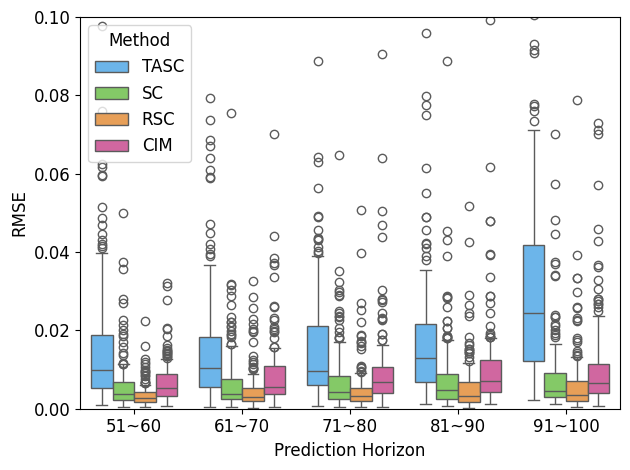

high_covariance: Q


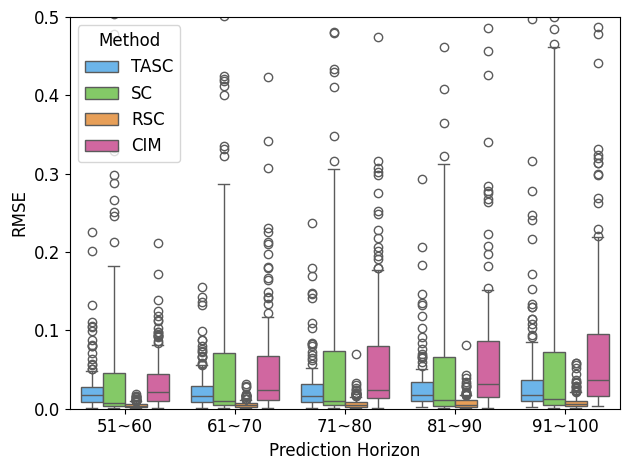

high_covariance: R


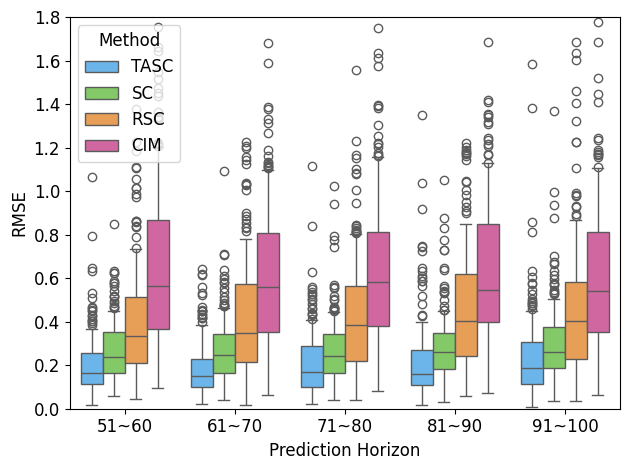

high_covariance: both


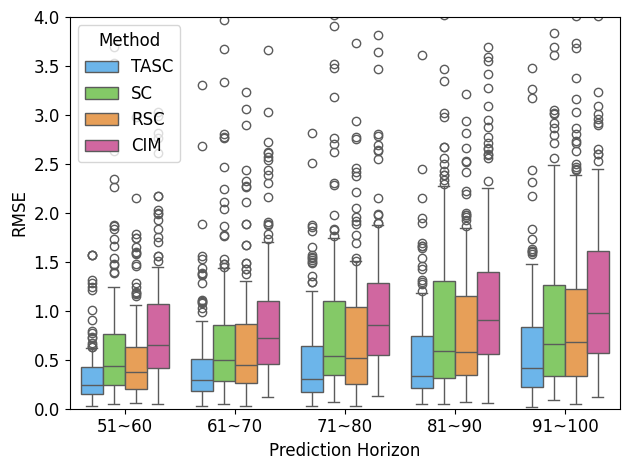

In [7]:
tops=[0.1, 0.5, 1.8, 4]
i=0
for variance in df["high_covariance"].unique():
    print("high_covariance:", variance)
    top = tops[i]
    i+=1

    df_plot = df_long
    df_plot = df_plot[df_plot["high_covariance"].isin([variance])]
    xticks = [0, 1, 2, 3, 4]
    xtickers = ["51~60", "61~70", "71~80", "81~90", "91~100"]
    hue_order = ["TASC", "SC", "RSC", "CIM"]
    font = 12

    # ax = sns.violinplot(
    ax = sns.boxplot(
        data=df_plot,
        x="period", 
        y="rmse",
        hue="method",        
        hue_order = hue_order,
        palette={"TASC": TASC_VColor, "RSC": RSC_VColor, "SC": SC_VColor, "CIM": CIM_VColor},
        whis = [0, 90],
        # linewidth=1.5,
        # inner="quartile",
        # cut=0
    )

    plt.xlabel("Prediction Horizon", fontsize=font)
    plt.ylabel("RMSE", fontsize=font)
    plt.xticks(xticks, xtickers, fontsize=font)
    plt.yticks(fontsize=font)
    plt.ylim(bottom=0, top=top)
    plt.legend(title="Method", fontsize=font, title_fontsize=font)
    plt.tight_layout()
    plt.savefig('exp1_per_period_{}.png'.format(variance))
    # plt.savefig('exp1_methods_comparison_smallR_{}.png'.format(outlier))
    plt.show()


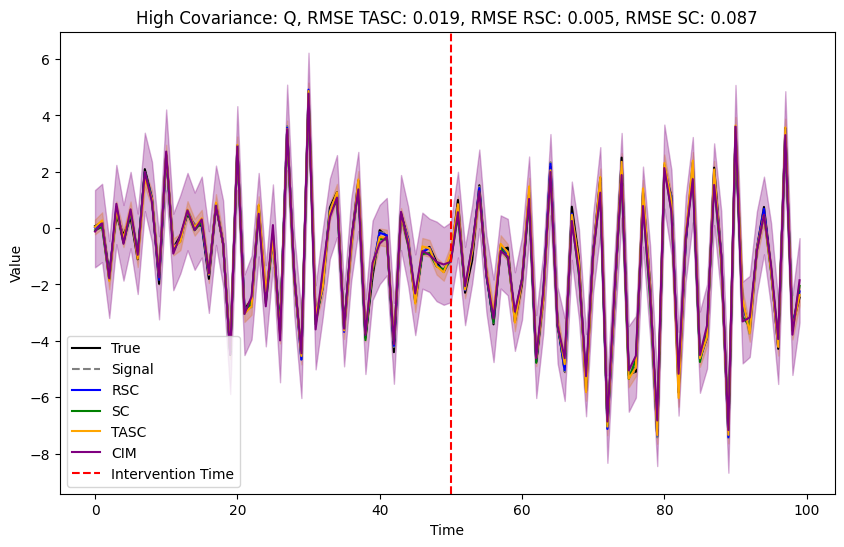

In [8]:
item_no = 1

selected_row = df.iloc[item_no]

list_cols = ['pred_tasc', 'pred_tasc_permute',
       'pred_rsc', 'pred_sc', 'pred_cim', 'cim_posterior_lower',
       'cim_posterior_upper', 'tasc_target_var_estimates','tasc_permute_target_var_estimates', 'ys', 'ys_signal']


plt.figure(figsize=(10,6))
plt.plot(selected_row["ys"], label='True', color='black')
plt.plot(selected_row["ys_signal"], label='Signal', color='gray', linestyle='--')
plt.plot(selected_row["pred_rsc"], label='RSC', color='blue')
plt.plot(selected_row["pred_sc"], label='SC', color='green')

plt.plot(selected_row["pred_tasc"], label='TASC', color='orange')
plt.fill_between(np.arange(selected_row["T"]), selected_row["tasc_lower"], selected_row["tasc_upper"], color='orange', alpha=0.3)

plt.plot(selected_row["pred_cim"], label='CIM', color='purple')
plt.fill_between(np.arange(selected_row["T"]), selected_row["cim_posterior_lower"], selected_row["cim_posterior_upper"], color='purple', alpha=0.3)

plt.axvline(x=selected_row["T0"], color='red', linestyle='--', label='Intervention Time')
plt.legend()
plt.title(f'High Covariance: {selected_row["high_covariance"]}, RMSE TASC: {selected_row["rmse_pred_tasc"]:.3f}, RMSE RSC: {selected_row["rmse_pred_rsc"]:.3f}, RMSE SC: {selected_row["rmse_pred_sc"]:.3f}')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()